In [1]:
!pip install polars astropy matplotlib seaborn umap-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyerfa-2.0.1.4-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 94.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 139.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 113.5 MB/s eta 0:00:00
Using cached pyerfa-2.0.1.4-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (738 kB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import warnings
warnings.simplefilter(action='ignore')

import os
import umap
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
import astropy
import seaborn

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from collections import OrderedDict


from dataloader import LSSTSourceDataSet
from taxonomy import class_map

%matplotlib inline

2024-09-09 19:59:00.302601: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-09 19:59:01.008745: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-09 19:59:01.010108: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-09 19:59:01.171897: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-09 19:59:01.486961: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Get the mean wavlengths for each filter and then convert to micro meteres
wavelengths = {
    'u': (320 + 400) / (2 * 1000),
    'g': (400 + 552) / (2 * 1000),
    'r': (552 + 691) / (2 * 1000),
    'i': (691 + 818) / (2 * 1000),
    'z': (818 + 922) / (2 * 1000),
    'Y': (950 + 1080) / (2 * 1000),
}

In [4]:
anomaly_map = OrderedDict({
                'SNII-NMF': 'common',
                'SNIc-Templates': 'common',
                'CART': 'anomaly',
                'EB': 'anomaly',
                'SNIc+HostXT_V19': 'common',
                'd-Sct': 'anomaly',
                'SNIb-Templates': 'common',
                'SNIIb+HostXT_V19': 'common',
                'SNIcBL+HostXT_V19': 'common',
                'CLAGN': 'anomaly',
                'PISN': 'anomaly',
                'Cepheid': 'anomaly',
                'TDE': 'common',
                'SNIa-91bg': 'common',
                'SLSN-I+host': 'common',
                'SNIIn-MOSFIT': 'common',
                'SNII+HostXT_V19': 'common',
                'SLSN-I_no_host': 'anomaly',
                'SNII-Templates': 'common',
                'SNIax': 'common',
                'SNIa-SALT3': 'common',
                'KN_K17': 'anomaly',
                'SNIIn+HostXT_V19': 'common',
                'dwarf-nova': 'anomaly',
                'uLens-Binary': 'anomaly',
                'RRL': 'anomaly',
                'Mdwarf-flare': 'anomaly',
                'ILOT': 'anomaly',
                'KN_B19': 'anomaly',
                'uLens-Single-GenLens': 'anomaly',
                'SNIb+HostXT_V19': 'common',
                'uLens-Single_PyLIMA': 'anomaly'
            })

ap_map = OrderedDict({
    class_map[key]: anomaly_map[key] for key in anomaly_map
})

anom_classes = []
non_anom_classes = []
classes = []

for key in ap_map:
    classes.append(key)
    if ap_map[key] == 'anomaly':
        anom_classes.append(key)
    else:
        non_anom_classes.append(key)
        
    
    
print(ap_map, anom_classes, non_anom_classes, len(anom_classes) + len(non_anom_classes))

OrderedDict([('SNII', 'common'), ('SNIb/c', 'common'), ('CART', 'anomaly'), ('EB', 'anomaly'), ('Delta Scuti', 'anomaly'), ('AGN', 'anomaly'), ('PISN', 'anomaly'), ('Cepheid', 'anomaly'), ('TDE', 'common'), ('SNI91bg', 'common'), ('SLSN', 'anomaly'), ('SNIax', 'common'), ('SNIa', 'common'), ('KN', 'anomaly'), ('Dwarf Novae', 'anomaly'), ('uLens', 'anomaly'), ('RR Lyrae', 'anomaly'), ('M-dwarf Flare', 'anomaly'), ('ILOT', 'anomaly')]) ['CART', 'EB', 'Delta Scuti', 'AGN', 'PISN', 'Cepheid', 'SLSN', 'KN', 'Dwarf Novae', 'uLens', 'RR Lyrae', 'M-dwarf Flare', 'ILOT'] ['SNII', 'SNIb/c', 'TDE', 'SNI91bg', 'SNIax', 'SNIa'] 19


## Restart here if data is saved.

In [5]:
# Load data
import pickle
def load(file_name):
    with open(file_name, 'rb') as f:
        return pickle.load(f)

target = load("processed/target.pkl")

# Converting the elasticc class to the astrophysical class
target = [class_map[e_class] for e_class in target]
x_data = load("processed/x_data.pkl")
host_galaxy_info = load("processed/host_galaxy_info.pkl")
print(np.unique(target), len(np.unique(target)))

['AGN' 'CART' 'Cepheid' 'Delta Scuti' 'Dwarf Novae' 'EB' 'ILOT' 'KN'
 'M-dwarf Flare' 'PISN' 'RR Lyrae' 'SLSN' 'SNI91bg' 'SNII' 'SNIa' 'SNIax'
 'SNIb/c' 'TDE' 'uLens'] 19


## Prepare arrays for Tensorflow

Typical Neural Networks require a fixed lenght input. However, Recurrent Neural Networks are capable of handling variable lengths, making them especially well-suited to time-series. However,  special, we can have a variable length. To use Tensorflow, we still need to provide a fixed length, but we can later using a Tensorflow Masking Layer to tell the RNN to ignore the extra time-steps later on. 

Let's find the maximum number of timesteps for any light curve in our dataset, and pad all light curves to that length

In [7]:
# Get number of observations for all light curves and get max number of timesteps 
lengths = []
for lc in x_data:
    lengths.append(len(lc))

ntimesteps = np.max(lengths)
print("Max timesteps is:", ntimesteps)

Max timesteps is: 146


In [8]:
# Pad for TF masking layer
for ind in range(len(x_data)):
    x_data[ind] = np.pad(x_data[ind], ((0, ntimesteps - len(x_data[ind])), (0, 0)))

In [9]:
# Split data into anomalous and normal classes and x inputs and y targets

y_data_anom = []
y_data_norm = []
x_data_norm = []
x_data_anom = []
host_gal_anom = []
host_gal = []

for i in range(len(target)):

    if (target[i] in anom_classes):
        x_data_anom.append(x_data[i])
        y_data_anom.append(target[i])
        host_gal_anom.append(host_galaxy_info[i])

    else:
        x_data_norm.append(x_data[i])
        y_data_norm.append(target[i])
        host_gal.append(host_galaxy_info[i])



In [10]:
# One-hot Encoding

from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore')

y_data_norm = enc.fit_transform(np.array(y_data_norm).reshape(-1, 1)).todense()

ved_norm_encoding = enc.categories_
ved_norm_encoding

[array(['SNI91bg', 'SNII', 'SNIa', 'SNIax', 'SNIb/c', 'TDE'], dtype='<U7')]

In [11]:
# Train-validation-test split: 80% training, 10% validation, 10% test 

X_train, X_test, host_gal_train, host_gal_test, y_train, y_test = train_test_split(x_data_norm, host_gal, y_data_norm, random_state = 40, test_size = 0.1)
X_train, X_val, host_gal_train, host_gal_val, y_train, y_val = train_test_split(X_train, host_gal_train, y_train, random_state = 40, test_size = 1/9)


In [12]:
# Get class_weights for imbalanced classes
class_weights = {i : 0 for i in range(y_train.shape[1])}

for value in y_train:
  class_weights[np.argmax(value)]+=1

for id in class_weights.keys():
  class_weights[id] = len(y_train) / class_weights[id]


class_weights

{0: 6.193018063730465,
 1: 5.849324259561008,
 2: 5.850445786597642,
 3: 6.363503649635036,
 4: 5.87466307277628,
 5: 5.907647628267183}

In [13]:
# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

X_test = np.array(X_test)
y_test = np.array(y_test)

host_gal_train = np.array(host_gal_train)
host_gal_test = np.array(host_gal_test)
host_gal_val = np.array(host_gal_val)

y_train = np.squeeze(y_train)
y_val = np.squeeze(y_val)
y_test = np.squeeze(y_test)
y_data_anom = np.squeeze(y_data_anom)

In [14]:
dummy = enc.transform(np.array(non_anom_classes).reshape(-1, 1))

ordered_class_names = non_anom_classes

In [15]:
# Generate Table for Training Counts

train_counts = {i : 0 for i in classes}

for i in y_train:
    train_counts[ordered_class_names[np.argmax(i)]] += 1
    
val_counts = {i : 0 for i in classes}

for i in y_val:
    val_counts[ordered_class_names[np.argmax(i)]] += 1
    
test_counts = {i : 0 for i in classes}

for i in y_test:
    test_counts[ordered_class_names[np.argmax(i)]] += 1

for i in y_data_anom:
    test_counts[i] += 1

In [16]:
full_data = {i: [] for i in classes}

for i in train_counts.keys():
    full_data[i].append(train_counts[i])
    
for i in val_counts.keys():
    full_data[i].append(val_counts[i])
    
for i in test_counts.keys():
    full_data[i].append(test_counts[i])

In [17]:
# Make Latex Table of counts for each training, validation, test, and all data (Table 1 in paper)
for key, value in full_data.items():
    print(f"{key} & {value[0]} & {value[1]} & {value[2]} & {value[1] + value[0] + value[2]} \\\\")
    print("\hline")


SNII & 9854 & 1182 & 1236 & 12272 \\
\hline
SNIb/c & 10433 & 1296 & 1271 & 13000 \\
\hline
CART & 0 & 0 & 3517 & 3517 \\
\hline
EB & 0 & 0 & 13000 & 13000 \\
\hline
Delta Scuti & 0 & 0 & 8849 & 8849 \\
\hline
AGN & 0 & 0 & 13000 & 13000 \\
\hline
PISN & 0 & 0 & 13000 & 13000 \\
\hline
Cepheid & 0 & 0 & 5901 & 5901 \\
\hline
TDE & 10431 & 1288 & 1281 & 13000 \\
\hline
SNI91bg & 9590 & 1192 & 1230 & 12012 \\
\hline
SLSN & 0 & 0 & 13000 & 13000 \\
\hline
SNIax & 10388 & 1351 & 1261 & 13000 \\
\hline
SNIa & 10330 & 1320 & 1350 & 13000 \\
\hline
KN & 0 & 0 & 1896 & 1896 \\
\hline
Dwarf Novae & 0 & 0 & 3439 & 3439 \\
\hline
uLens & 0 & 0 & 7537 & 7537 \\
\hline
RR Lyrae & 0 & 0 & 6014 & 6014 \\
\hline
M-dwarf Flare & 0 & 0 & 796 & 796 \\
\hline
ILOT & 0 & 0 & 3197 & 3197 \\
\hline


## Neural Network Classifier

Here, we develop a GRU RNN architecture. You can change this model to suit your classification

Function to make model. Here you'll need to design the architecture. You'll probably just need to change the input shape for the input layers (commented with CHANGE) depending on whether you use host galaxy information or not.

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, TimeDistributed, Dense, Masking, concatenate, GRU
from tensorflow.keras.callbacks import EarlyStopping
from math import dist

def make_classifier_model(latent_size):

    num_classes = len(class_weights)
    n_features = 4

    input_1 = Input((ntimesteps, n_features), name='lc')  # X.shape = (Nobjects, Ntimesteps, 4) CHANGE

    masking_input1 = Masking(mask_value=0.)(input_1)

    lstm1 = GRU(100, return_sequences=True, activation='tanh')(masking_input1)
    lstm2 = GRU(100, return_sequences=False, activation='tanh')(lstm1)

    dense1 = Dense(100, activation='tanh')(lstm2)

    input_2 = Input(shape = (1, ), name='host') # CHANGE

    dense2 = Dense(10)(input_2)

    merge1 = concatenate([dense1, dense2])

    dense3 = Dense(100, activation='relu')(merge1)

    dense4 = Dense(latent_size, activation='relu', name='latent')(dense3)

    output = Dense(num_classes, activation='softmax')(dense4)

    model = keras.Model(inputs=[input_1, input_2], outputs=output)

    model.compile(loss = "categorical_crossentropy", optimizer="adam", metrics=['accuracy'])
    
    return model

In [20]:
model = keras.models.load_model('../models/FinalModel.keras')

model.get_layer('dense_5').get_weights() # Redshift layer

2024-08-29 14:31:09.396398: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1926] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31127 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:b3:00.0, compute capability: 7.0


[array([[-1.0005823 ,  1.1267745 , -1.5067755 , -1.4596039 , -1.1315933 ,
         -1.1381758 , -1.1414452 , -1.2697906 ,  1.359298  , -1.0522509 ],
        [-0.04276255, -0.01704434,  0.551397  , -0.6816117 , -0.4692231 ,
          0.12756507,  0.21055785,  0.4209234 ,  0.787831  ,  0.11764055]],
       dtype=float32),
 array([ 0.08821003, -0.09240124,  0.07532988,  0.09724057,  0.095958  ,
         0.08974022,  0.08017437,  0.07780169, -0.09483181,  0.09134094],
       dtype=float32)]

In [21]:
model = keras.models.load_model('../models/FinalModel.keras')

def from_base_model(latent_size, tr=True):
    model = keras.models.load_model('../models/FinalModel.keras')
    num_classes = len(class_weights)
    n_features = 4

    input_1 = Input((ntimesteps, n_features), name='lc')  # X.shape = (Nobjects, Ntimesteps, 4) CHANGE

    masking_input1 = Masking(mask_value=0.)(input_1)

    lstm1 = GRU(100, return_sequences=True, activation='tanh', name='gru', trainable=True)(masking_input1)
    lstm2 = GRU(100, return_sequences=False, activation='tanh', name='gru_1', trainable=True)(lstm1)

    dense1 = Dense(100, activation='tanh', name='dense_4', trainable=tr)(lstm2)

    input_2 = Input(shape = (1, ), name='host') # CHANGE

    dense2 = Dense(10, name='dense_5', trainable=tr)(input_2)

    merge1 = concatenate([dense1, dense2])

    dense3 = Dense(100, activation='relu', name='dense_6', trainable=tr)(merge1)

    dense4 = Dense(100, activation='relu', name='latent', trainable=True)(dense3)

    output = Dense(12, activation='softmax', name='output')(dense4)
    
    

    new_model = Model(inputs=[input_1, input_2], outputs=output)


    layers = ['gru', 'gru_1', 'dense_4', 'dense_6']
    
    for i in layers:
        new_model.get_layer(i).set_weights(model.get_layer(i).get_weights())
        print(i)
        
    
        
    new_model.get_layer('dense_5').set_weights([model.get_layer('dense_5').get_weights()[0][1:], model.get_layer('dense_5').get_weights()[1]]) # Remove redshift as an input

    additional_layer = Dense(100, activation='relu', trainable=True)(dense4)
    additional_layer2 = Dense(100, activation='relu', trainable=True)(additional_layer)
    additional_layer3 = Dense(100, activation='relu', trainable=True)(additional_layer2)
    
    new_output = Dense(num_classes, activation='softmax', name='output')(additional_layer2)
    
    new_model = Model(inputs=[input_1, input_2], outputs=new_output)

    new_model.compile(loss = "categorical_crossentropy", optimizer="adam", metrics=['accuracy'])
    return new_model

In [22]:
# Removing passbands

# rev_map = {i:ind/6 for ind, i in enumerate(np.unique(X_train[:, :, 3]))}
# def rev(x):
#     if x in rev_map.keys():
#         return rev_map[x]
#     else:
#         return x

# for i in range(len(X_train)):
#     X_train[i][:, 3] = (np.array(list(map(rev, X_train[i][:, 3]))))
    
# for i in range(len(X_val)):
#     X_val[i][:, 3] = (np.array(list(map(rev, X_val[i][:, 3]))))
    
# for i in range(len(X_test)):
#     X_test[i][:, 3] = (np.array(list(map(rev, X_test[i][:, 3]))))
    
# for i in range(len(x_data_anom)):
#     x_data_anom[i][:, 3] = (np.array(list(map(rev, x_data_anom[i][:, 3]))))

In [ ]:
latent_size=100
# model = make_classifier_model(latent_size) # HERE YOU CAN CHANGE THE LATENT SPACE SIZE
model = from_base_model(latent_size, False)
# # model.summary()
early_stopping = EarlyStopping(
                              patience=3,
                              min_delta=0.001,                               
                              monitor="val_loss",
                              restore_best_weights=True
                              )



try:
    history = model.fit(x = [X_train, host_gal_train], validation_data=([X_val, host_gal_val], y_val), y = y_train, epochs=40, batch_size = 128, class_weight = class_weights, callbacks=[early_stopping])
except Exception as e:
    print(e)
    pass

In [23]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

def get_auroc_cls(y_pred, y_true_bin):

    auroc_per_class = roc_auc_score(y_true_bin, y_pred, average=None)
    

    macro_auroc = roc_auc_score(y_true_bin, y_pred, average='macro')
    

    micro_auroc = roc_auc_score(y_true_bin, y_pred, average='micro')
    
    return auroc_per_class, macro_auroc, micro_auroc

In [24]:
y_true = [np.argmax(i) for i in y_test]



In [25]:
num_classes = len(non_anom_classes)

In [26]:
y_test.shape

(7629, 6)

In [28]:
import random
early_stopping = EarlyStopping(
                              patience=5,
                              min_delta=0.001,                               
                              monitor="val_loss",
                              restore_best_weights=True
                              )

by_class = {i : [] for i in range(num_classes)}

for i in range(len(X_train)):
    by_class[np.argmax(y_train[i])].append(i)
    
by_clas_val = {i : [] for i in range(num_classes)}

for i in range(len(X_val)):
    by_clas_val[np.argmax(y_val[i])].append(i)


sample_size = []
trans = []
norm = []
epochs_norm = []
epochs_tran = []

for i in range(3):
    for data_sample in [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 5000, 7000, 9000]:

        X_train_sub = []
        y_train_sub = []
        X_val_sub = []
        y_val_sub = []
        host_gal_sub = []
        host_val_sub = []
        for cls in range((num_classes)):
            inds = random.sample(by_class[cls], round(0.9 * data_sample))
            X_train_sub.extend(X_train[inds])
            y_train_sub.extend(y_train[inds])
            host_gal_sub.extend(host_gal_train[inds])
            
            val_inds = random.sample(by_clas_val[cls], round(0.1 * data_sample))
            X_val_sub.extend(X_train[val_inds])
            y_val_sub.extend(y_train[val_inds])
            host_val_sub.extend(host_gal_train[val_inds])

        X_train_sub = np.array(X_train_sub)
        y_train_sub = np.array(y_train_sub)   
        host_gal_sub = np.array(host_gal_sub)
        
        X_val_sub = np.array(X_val_sub)
        y_val_sub = np.array(y_val_sub)   
        host_val_sub = np.array(host_val_sub)
        
        
#         print(X_train_sub.shape)

        latent_size=100
        base_model = from_base_model(latent_size, False)
        hb = base_model.fit(x = [X_train_sub, host_gal_sub], validation_data=([X_val_sub, host_val_sub], y_val_sub), y = y_train_sub, epochs=100, batch_size = 128, callbacks=[early_stopping])

        y_pred = base_model.predict([X_test, host_gal_test])    
        trans_perf = (get_auroc_cls(y_pred, y_test))
#         norm_perf=-1

        classifier = make_classifier_model(latent_size)
        hc = classifier.fit(x = [X_train_sub, host_gal_sub], validation_data=([X_val_sub, host_val_sub], y_val_sub), y = y_train_sub, epochs=100, batch_size = 128, callbacks=[early_stopping])

        y_pred = classifier.predict([X_test, host_gal_test])    
        norm_perf = (get_auroc_cls(y_pred, y_test))


        sample_size.append(data_sample)
        trans.append(trans_perf)
        norm.append(norm_perf)
        
        epochs_norm.append(len(hc.history['loss']))
        epochs_tran.append(len(hb.history['loss']))
        
        
        print(data_sample, i, trans_perf[1], norm_perf[1])
    
        
#         save( '../LotsZTFtoLSST3', zip(sample_size, trans, norm, epochs_norm, epochs_tran))

    

gru
gru_1
dense_4
dense_6
Epoch 1/100
5/5 [==============================] - 8s 444ms/step - loss: 1.8173 - accuracy: 0.1630 - val_loss: 1.7863 - val_accuracy: 0.1500
Epoch 2/100
5/5 [==============================] - 0s 24ms/step - loss: 1.7821 - accuracy: 0.2037 - val_loss: 1.7837 - val_accuracy: 0.2000
Epoch 3/100
5/5 [==============================] - 0s 23ms/step - loss: 1.7720 - accuracy: 0.2111 - val_loss: 1.7606 - val_accuracy: 0.2667
Epoch 4/100
5/5 [==============================] - 0s 21ms/step - loss: 1.7531 - accuracy: 0.2222 - val_loss: 1.7684 - val_accuracy: 0.1833
Epoch 5/100
5/5 [==============================] - 0s 22ms/step - loss: 1.7399 - accuracy: 0.2352 - val_loss: 1.7526 - val_accuracy: 0.1167
Epoch 6/100
5/5 [==============================] - 0s 21ms/step - loss: 1.7299 - accuracy: 0.2296 - val_loss: 1.7603 - val_accuracy: 0.1000
Epoch 7/100
5/5 [==============================] - 0s 22ms/step - loss: 1.7277 - accuracy: 0.2537 - val_loss: 1.7545 - val_accuracy: 

13/13 [==============================] - 0s 17ms/step - loss: 1.7734 - accuracy: 0.1846 - val_loss: 1.7792 - val_accuracy: 0.1667
Epoch 9/100
13/13 [==============================] - 0s 17ms/step - loss: 1.7721 - accuracy: 0.1938 - val_loss: 1.7777 - val_accuracy: 0.1833
Epoch 10/100
239/239 [==============================] - 3s 4ms/step
300 0 0.7391614756487566 0.5189944069140281
gru
gru_1
dense_4
dense_6
Epoch 1/100
17/17 [==============================] - 8s 130ms/step - loss: 1.8009 - accuracy: 0.1630 - val_loss: 1.7947 - val_accuracy: 0.1667
Epoch 2/100
17/17 [==============================] - 0s 17ms/step - loss: 1.7828 - accuracy: 0.1843 - val_loss: 1.7943 - val_accuracy: 0.1667
Epoch 3/100
17/17 [==============================] - 0s 18ms/step - loss: 1.7760 - accuracy: 0.2028 - val_loss: 1.7933 - val_accuracy: 0.1792
Epoch 4/100
17/17 [==============================] - 0s 17ms/step - loss: 1.7684 - accuracy: 0.2079 - val_loss: 1.7852 - val_accuracy: 0.1583
Epoch 5/100
17/17 [==

26/26 [==============================] - 0s 16ms/step - loss: 1.2004 - accuracy: 0.5099 - val_loss: 1.3223 - val_accuracy: 0.4556
Epoch 38/100
26/26 [==============================] - 0s 16ms/step - loss: 1.1986 - accuracy: 0.5040 - val_loss: 1.2924 - val_accuracy: 0.4722
Epoch 39/100
26/26 [==============================] - 0s 16ms/step - loss: 1.1889 - accuracy: 0.5151 - val_loss: 1.3382 - val_accuracy: 0.4778
Epoch 40/100
26/26 [==============================] - 0s 16ms/step - loss: 1.1779 - accuracy: 0.5123 - val_loss: 1.3248 - val_accuracy: 0.4500
Epoch 41/100
26/26 [==============================] - 0s 16ms/step - loss: 1.1514 - accuracy: 0.5228 - val_loss: 1.3163 - val_accuracy: 0.4694
Epoch 42/100
26/26 [==============================] - 0s 16ms/step - loss: 1.1206 - accuracy: 0.5432 - val_loss: 1.3172 - val_accuracy: 0.4667
Epoch 43/100
239/239 [==============================] - 3s 4ms/step
600 0 0.767789204164978 0.7898619289235947
gru
gru_1
dense_4
dense_6
Epoch 1/100
30/30 

Epoch 3/100
38/38 [==============================] - 1s 16ms/step - loss: 1.7876 - accuracy: 0.1749 - val_loss: 1.7788 - val_accuracy: 0.2000
Epoch 4/100
38/38 [==============================] - 1s 16ms/step - loss: 1.7869 - accuracy: 0.1706 - val_loss: 1.7842 - val_accuracy: 0.1611
Epoch 5/100
38/38 [==============================] - 1s 16ms/step - loss: 1.7862 - accuracy: 0.1735 - val_loss: 1.7844 - val_accuracy: 0.1778
Epoch 6/100
38/38 [==============================] - 1s 15ms/step - loss: 1.7853 - accuracy: 0.1831 - val_loss: 1.7804 - val_accuracy: 0.1907
Epoch 7/100
38/38 [==============================] - 1s 15ms/step - loss: 1.7849 - accuracy: 0.1780 - val_loss: 1.7835 - val_accuracy: 0.1704
Epoch 8/100
38/38 [==============================] - 1s 16ms/step - loss: 1.7835 - accuracy: 0.1809 - val_loss: 1.7764 - val_accuracy: 0.2019
Epoch 9/100
38/38 [==============================] - 1s 16ms/step - loss: 1.7840 - accuracy: 0.1897 - val_loss: 1.7791 - val_accuracy: 0.2000
Epoch 

85/85 [==============================] - 1s 15ms/step - loss: 1.4596 - accuracy: 0.3681 - val_loss: 1.4590 - val_accuracy: 0.3650
Epoch 5/100
85/85 [==============================] - 1s 15ms/step - loss: 1.3827 - accuracy: 0.4051 - val_loss: 1.3518 - val_accuracy: 0.4067
Epoch 6/100
85/85 [==============================] - 1s 15ms/step - loss: 1.3178 - accuracy: 0.4362 - val_loss: 1.2916 - val_accuracy: 0.4500
Epoch 7/100
85/85 [==============================] - 1s 15ms/step - loss: 1.2596 - accuracy: 0.4658 - val_loss: 1.2960 - val_accuracy: 0.4542
Epoch 8/100
85/85 [==============================] - 1s 15ms/step - loss: 1.2399 - accuracy: 0.4758 - val_loss: 1.2471 - val_accuracy: 0.4800
Epoch 9/100
85/85 [==============================] - 1s 15ms/step - loss: 1.1948 - accuracy: 0.5045 - val_loss: 1.2313 - val_accuracy: 0.5042
Epoch 10/100
85/85 [==============================] - 1s 15ms/step - loss: 1.1853 - accuracy: 0.5039 - val_loss: 1.2021 - val_accuracy: 0.5075
Epoch 11/100
85/8

...

38/38 [==============================] - 1s 16ms/step - loss: 1.0914 - accuracy: 0.5525 - val_loss: 1.2036 - val_accuracy: 0.4981
Epoch 41/100
38/38 [==============================] - 1s 16ms/step - loss: 1.0703 - accuracy: 0.5510 - val_loss: 1.1626 - val_accuracy: 0.5167
Epoch 42/100
38/38 [==============================] - 1s 16ms/step - loss: 1.0505 - accuracy: 0.5718 - val_loss: 1.1581 - val_accuracy: 0.5130
Epoch 43/100
38/38 [==============================] - 1s 15ms/step - loss: 1.0311 - accuracy: 0.5749 - val_loss: 1.1641 - val_accuracy: 0.5259
Epoch 44/100
38/38 [==============================] - 1s 16ms/step - loss: 1.0104 - accuracy: 0.5885 - val_loss: 1.1719 - val_accuracy: 0.5278
Epoch 45/100
38/38 [==============================] - 1s 16ms/step - loss: 0.9836 - accuracy: 0.6002 - val_loss: 1.1723 - val_accuracy: 0.5389
Epoch 46/100
38/38 [==============================] - 1s 15ms/step - loss: 0.9808 - accuracy: 0.5977 - val_loss: 1.1585 - val_accuracy: 0.5167
Epoch 47/100

85/85 [==============================] - 1s 15ms/step - loss: 1.7705 - accuracy: 0.2082 - val_loss: 1.7669 - val_accuracy: 0.2092
Epoch 8/100
85/85 [==============================] - 1s 16ms/step - loss: 1.7518 - accuracy: 0.2332 - val_loss: 1.6826 - val_accuracy: 0.2592
Epoch 9/100
85/85 [==============================] - 1s 15ms/step - loss: 1.5878 - accuracy: 0.3215 - val_loss: 1.5151 - val_accuracy: 0.3500
Epoch 10/100
85/85 [==============================] - 1s 15ms/step - loss: 1.4908 - accuracy: 0.3583 - val_loss: 1.4421 - val_accuracy: 0.3808
Epoch 11/100
85/85 [==============================] - 1s 15ms/step - loss: 1.4258 - accuracy: 0.3892 - val_loss: 1.4073 - val_accuracy: 0.3908
Epoch 12/100
85/85 [==============================] - 1s 16ms/step - loss: 1.3536 - accuracy: 0.4236 - val_loss: 1.3751 - val_accuracy: 0.4158
Epoch 13/100
85/85 [==============================] - 1s 15ms/step - loss: 1.3023 - accuracy: 0.4511 - val_loss: 1.3338 - val_accuracy: 0.4425
Epoch 14/100
8

211/211 [==============================] - 3s 15ms/step - loss: 0.8168 - accuracy: 0.6723 - val_loss: 0.9579 - val_accuracy: 0.6227
Epoch 26/100
211/211 [==============================] - 3s 15ms/step - loss: 0.8018 - accuracy: 0.6797 - val_loss: 0.9419 - val_accuracy: 0.6293
Epoch 27/100
211/211 [==============================] - 3s 15ms/step - loss: 0.7852 - accuracy: 0.6892 - val_loss: 0.9564 - val_accuracy: 0.6297
Epoch 28/100
211/211 [==============================] - 3s 15ms/step - loss: 0.7713 - accuracy: 0.6936 - val_loss: 0.9620 - val_accuracy: 0.6370
Epoch 29/100
211/211 [==============================] - 3s 15ms/step - loss: 0.7647 - accuracy: 0.6947 - val_loss: 0.9399 - val_accuracy: 0.6460
Epoch 30/100
211/211 [==============================] - 3s 15ms/step - loss: 0.7431 - accuracy: 0.7060 - val_loss: 0.9492 - val_accuracy: 0.6427
Epoch 31/100
211/211 [==============================] - 3s 15ms/step - loss: 0.7340 - accuracy: 0.7074 - val_loss: 0.9457 - val_accuracy: 0.650

296/296 [==============================] - 5s 16ms/step - loss: 0.7420 - accuracy: 0.7085 - val_loss: 0.8348 - val_accuracy: 0.6760
Epoch 27/100
296/296 [==============================] - 5s 16ms/step - loss: 0.7328 - accuracy: 0.7100 - val_loss: 0.8253 - val_accuracy: 0.6776
Epoch 28/100
296/296 [==============================] - 5s 16ms/step - loss: 0.7205 - accuracy: 0.7160 - val_loss: 0.7996 - val_accuracy: 0.6900
Epoch 29/100
296/296 [==============================] - 5s 16ms/step - loss: 0.7039 - accuracy: 0.7234 - val_loss: 0.8346 - val_accuracy: 0.6776
Epoch 30/100
296/296 [==============================] - 5s 16ms/step - loss: 0.6952 - accuracy: 0.7276 - val_loss: 0.8125 - val_accuracy: 0.6867
Epoch 31/100
296/296 [==============================] - 5s 16ms/step - loss: 0.6792 - accuracy: 0.7344 - val_loss: 0.8186 - val_accuracy: 0.6888
Epoch 32/100
296/296 [==============================] - 5s 16ms/step - loss: 0.6624 - accuracy: 0.7409 - val_loss: 0.7961 - val_accuracy: 0.697

Epoch 39/100
380/380 [==============================] - 6s 16ms/step - loss: 0.6384 - accuracy: 0.7495 - val_loss: 0.7203 - val_accuracy: 0.7324
Epoch 40/100
380/380 [==============================] - 6s 15ms/step - loss: 0.6337 - accuracy: 0.7526 - val_loss: 0.7066 - val_accuracy: 0.7406
Epoch 41/100
380/380 [==============================] - 6s 15ms/step - loss: 0.6151 - accuracy: 0.7585 - val_loss: 0.7096 - val_accuracy: 0.7480
Epoch 42/100
380/380 [==============================] - 6s 15ms/step - loss: 0.6110 - accuracy: 0.7604 - val_loss: 0.6821 - val_accuracy: 0.7556
Epoch 43/100
380/380 [==============================] - 6s 16ms/step - loss: 0.5970 - accuracy: 0.7664 - val_loss: 0.7164 - val_accuracy: 0.7402
Epoch 44/100
380/380 [==============================] - 6s 15ms/step - loss: 0.5893 - accuracy: 0.7684 - val_loss: 0.6989 - val_accuracy: 0.7496
Epoch 45/100
380/380 [==============================] - 6s 15ms/step - loss: 0.5841 - accuracy: 0.7714 - val_loss: 0.7046 - val_ac

In [31]:
save( '../LotsZTFtoLSST', zip(sample_size, trans, norm, epochs_norm, epochs_tran))

In [33]:
for i in range(len(norm)):
    print(norm[i], trans[i])

(array([0.50386604, 0.51079982, 0.49788386, 0.53111373, 0.53609817,
       0.5398687 ]), 0.5199383850704944, 0.5155427335803127) (array([0.52710679, 0.52858303, 0.50365498, 0.54264608, 0.52597575,
       0.58443052]), 0.5353995249676001, 0.5357476827844081)
(array([0.52150897, 0.52513458, 0.5011313 , 0.54496193, 0.54637307,
       0.56667463]), 0.5342974146698195, 0.5305717977951858) (array([0.76544266, 0.63663378, 0.6129232 , 0.62959806, 0.63287231,
       0.91154772]), 0.6981696196378983, 0.7175182122442217)
(array([0.51001259, 0.51547392, 0.49788036, 0.52895746, 0.53652612,
       0.525116  ]), 0.5189944069140281, 0.5175099650540781) (array([0.81971407, 0.69336388, 0.66320771, 0.66152911, 0.65243134,
       0.94472274]), 0.7391614756487566, 0.7596157606621435)
(array([0.50731155, 0.50438156, 0.49657271, 0.52559318, 0.52270615,
       0.52443619]), 0.5135002226586298, 0.5098720171824709) (array([0.8153625 , 0.66895693, 0.66334956, 0.66696607, 0.66490007,
       0.94447087]), 0.737334

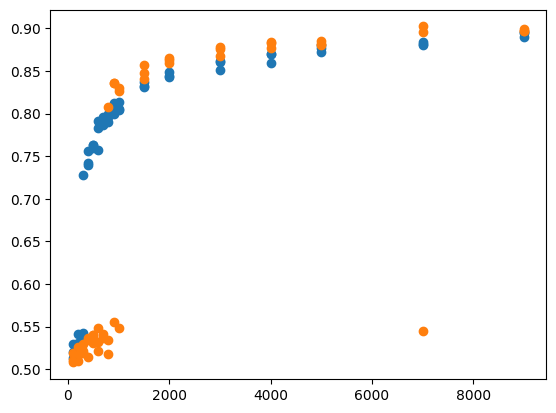

In [29]:
plt.scatter(sample_size, [i[1] for i in trans])
plt.scatter(sample_size, [i[1] for i in norm])

In [74]:
# vals = zip(sample_size, t)
# save( '../LotsZTFtoLSST2', zip(sample_size, trans, norm))
vals = load('../LotsZTFtoLSST')
norm_perf = {}
trans_perf = {}
for i in vals:
    if (i[0] not in norm_perf):
        norm_perf[i[0]]=[]
        trans_perf[i[0]]=[]
    norm_perf[i[0]].append(i[2][1])
    trans_perf[i[0]].append(i[1][1])    


In [75]:
norm_perf.keys()

dict_keys([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 5000, 7000, 9000])

In [77]:
norm_err = {}
trans_err = {}
for i in norm_perf.keys():
    trans_err[i] = (np.std(trans_perf[i])) # np.median(np.abs(trans_perf[i] - np.median(trans_perf[i])))
    norm_err[i] = (np.std(norm_perf[i])) # np.median(np.abs(norm_perf[i] - np.median(norm_perf[i])))
    
    norm_perf[i]=np.mean(norm_perf[i])
    trans_perf[i]=np.mean(trans_perf[i])


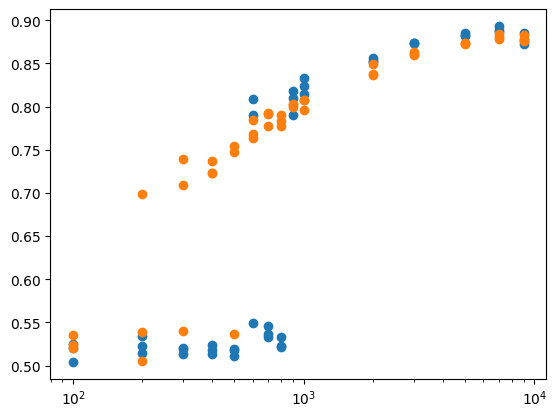

In [78]:
plt.scatter(sample_size, [i[1] for i in norm])
plt.scatter(sample_size, [i[1] for i in trans])

plt.xscale('log')

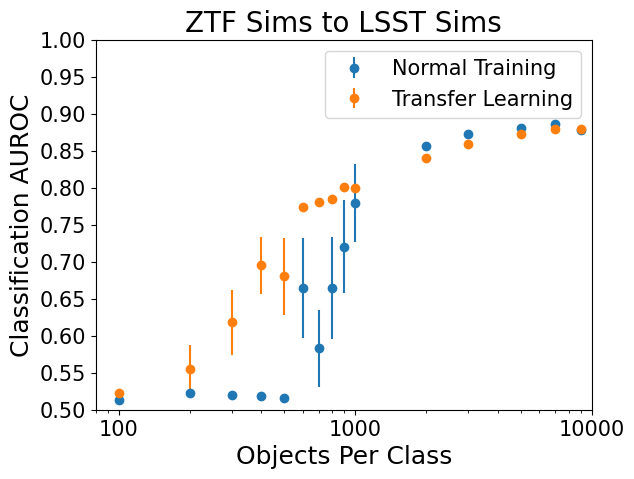

In [81]:
fig, ax= plt.subplots()

ax.errorbar(norm_perf.keys(), norm_perf.values(), yerr=list(norm_err.values()), linestyle='None', marker='o', label='Normal Training')
ax.errorbar(trans_perf.keys(), trans_perf.values(), yerr=list(trans_err.values()), label='Transfer Learning', linestyle='None', marker='o')
ax.set_xlabel('Objects Per Class', fontsize=18)
ax.set_ylabel('Classification AUROC', fontsize=18)
ax.legend(fontsize=15)
ax.set_title('ZTF Sims to LSST Sims', fontsize=20)
ax.set_xscale('log')
# ax.set_xticks(list(norm_perf.keys()))
plt.xlim((80, 10000))
# plt.vlines(list(norm_perf.keys()), 0.5, 2, linestyles='dotted', color='grey')
ax.set_yticks(np.arange(0.5, 1.01, 0.05))
plt.ylim(0.5, 1)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

saveplot('../transfer/ZTFtoLSSTGranular3')